In [221]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [222]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [223]:
weight=0.3
bias=0.7
x=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=bias+x*weight
x[:5],y[:5]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800]]),
 tensor([[0.7000],
         [0.7060],
         [0.7120],
         [0.7180],
         [0.7240]]))

In [224]:
split_size=int(len(x)*0.8)
x_train,y_train=x[:split_size],y[:split_size]
x_test,y_test=x[split_size:],y[split_size:]


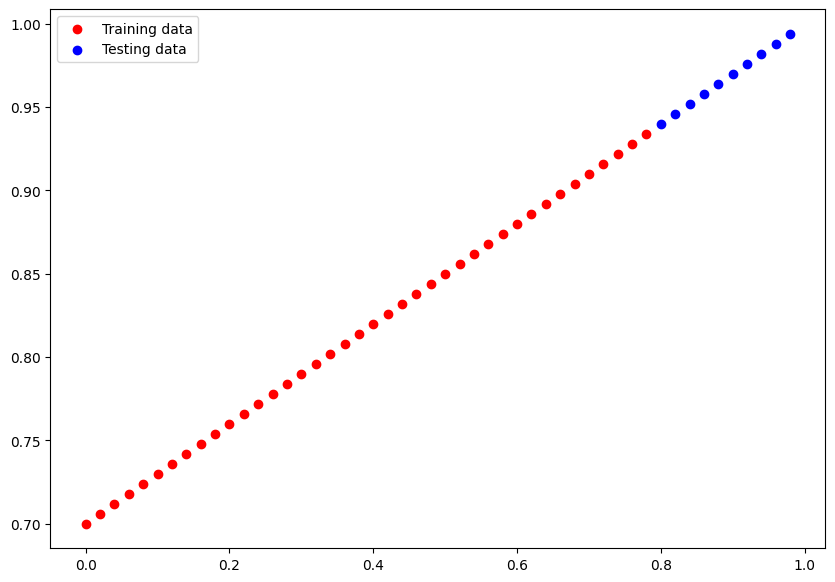

In [225]:
from numpy import size
def plot_predictions(train_data=x_train,
                     train_label=y_train,
                     test_data=x_test,
                     test_label=y_test,
                     predictions=None):
  plt.figure(figsize=(10,7))
  plt.scatter(train_data,train_label,c='r',label="Training data")
  plt.scatter(test_data,test_label,c='b',label="Testing data")
  if predictions is not None:
    plt.scatter(test_data,predictions,c='g',label="predictions data")
  plt.legend(prop={'size':10})
plot_predictions()

In [226]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.Linear_model=nn.Linear(in_features=1,out_features=1)
  def forward(self,x):
    return self.Linear_model(x)

In [227]:
model_0=LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([[-0.5445]], requires_grad=True),
 Parameter containing:
 tensor([0.7194], requires_grad=True)]

In [228]:
loss_fun=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.01)

In [229]:
epochs=500
epoch_list=[]
loss_list=[]
test_loss_list=[]
for epoch in range(epochs):
  model_0.train()
  y_pred=model_0(x_train)
  loss=loss_fun(y_pred,y_train)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  model_0.eval()
  with torch.inference_mode():
    y_pred_test=model_0(x_test)
    loss_test=loss_fun(y_pred_test,y_test)
    if epoch%10==0:
      epoch_list.append(epoch)
      loss_list.append(loss.item())
      test_loss_list.append(loss_test.item())


In [230]:
model_0.state_dict()

OrderedDict([('Linear_model.weight', tensor([[0.2913]])),
             ('Linear_model.bias', tensor([0.6989]))])

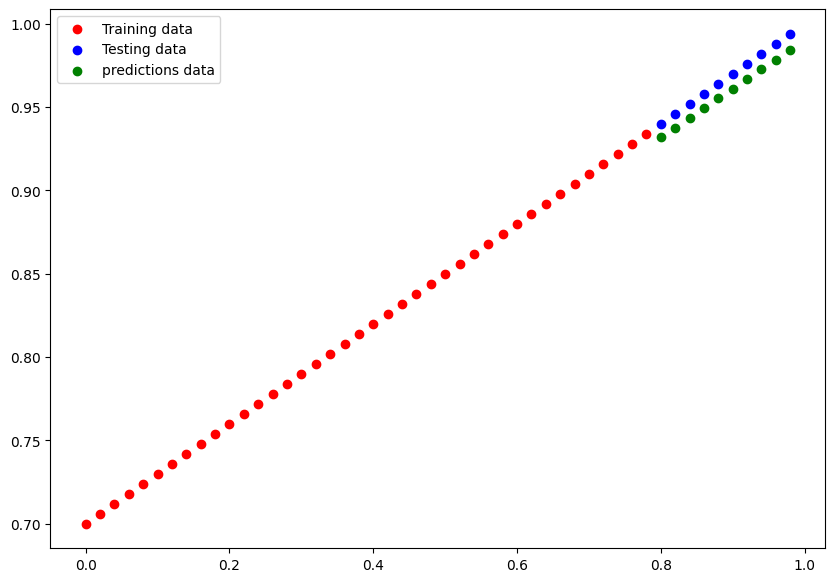

In [231]:
with torch.inference_mode():
  y_preds=model_0(x_test)
  y_preds_loss=loss_fun(y_preds,y_test)
plot_predictions(predictions=y_preds)

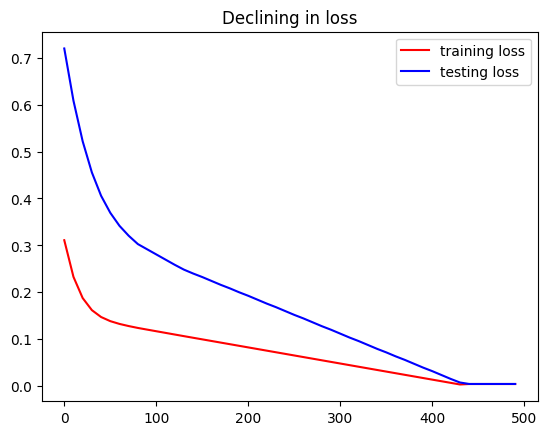

In [232]:
plt.title("Declining in loss")
plt.plot(epoch_list,loss_list,c='r',label="training loss")
plt.plot(epoch_list,test_loss_list,c='b',label="testing loss")
plt.legend()


In [233]:
from pathlib import Path
model_path=Path('files')
model_path.mkdir(exist_ok=True)
model_name="Pytorch_1.pth"
model_save_path=model_path/model_name
torch.save(obj=model_0.state_dict(),f=model_save_path)

In [234]:
loaded_model_0=LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f=model_save_path))

<All keys matched successfully>

In [235]:
loaded_model_0.eval()
with torch.inference_mode():
  y_pred_2=loaded_model_0(x_test)
  loaded_model_0_loss=loss_fun(y_pred_2,y_test)
print(y_pred_2==y_preds)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])


In [236]:
loaded_model_0_loss==y_preds_loss

tensor(True)